In [3]:
def computeCentrality(layers, alpha = lambda x : 1/x):
    c = 0
    for dist, layer_size in enumerate(layers):
            c += layer_size*alpha(dist+1)
    return c

# load data from files
def loadLines(file_path):
        with open(file_path, 'r') as f:
                lines = [list(map(int, line.split())) for line in f.readlines()]
        return lines

def loadData(file_path):
        lines = loadLines(file_path)
        # now we want a list of (id, (l1_exact, l2_exact), [layers]))
        # where layers is a list of the number of nodes in each layer
        data = []
        for line in lines:
                id = line[0]
                h1_ball = line[1]
                h2_ball = line[2]
                layers = line[3:]
                data.append((id, (h1_ball, h2_ball-h1_ball), layers))
        return data 

def computeCentralityForDataset(data, alpha = lambda x : 1/x):
        # compute the centrality for each node in the data
        centralities = []
        trunkated_centralities_exact = []
        trunkated_centralities_appx = []
        ids = []
        for id, trunkated_layers, layers in data:
                c = computeCentrality(layers, alpha)
                c_trunkated_exact = computeCentrality(layers[:2], alpha)
                c_trunkated_appx = computeCentrality(trunkated_layers, alpha)
                centralities.append(c)
                trunkated_centralities_exact.append(c_trunkated_exact)
                trunkated_centralities_appx.append(c_trunkated_appx)
                ids.append(id)
        return ids, centralities, trunkated_centralities_exact, trunkated_centralities_appx

datasets = ["comm-linux-kernel-reply","fb-wosn-friends","ia-enron-email-all","ca-cit-HepTh"]

# Full centrality vs truncated centrality (Harmonic)

In this section, we compare the **exact complete centrality** with the **truncated centrality**, both of which are either approximated or computed exactly. Note that since the x-axis represents the target values, the comparison between the approximated centrality and the exact full centrality can be made by observing the $x=y$ line, which is shown in the plots.

In [76]:
import matplotlib.pyplot as plt
import numpy as np

# experiment code
def plotCentralities(ax, snap, dataset, alpha = lambda x : 1/x):

    ids, centralities, trunkated_centralities_exact, trunkated_centralities_appx  = computeCentralityForDataset(dataset, alpha)

    full_to_trunkated = [(x,y,w,z) for x,y, w, z in zip(centralities, trunkated_centralities_exact, trunkated_centralities_appx, ids)]
    full_to_trunkated.sort(key=lambda x: x[0])
    centralities, trunkated_centralities_exact, trunkated_centralities_appx, ids = zip(*full_to_trunkated)

    ax.scatter(
        centralities, trunkated_centralities_appx,
        label='Truncated Centrality (Approx)', color='red', 
        marker='s', alpha=0.5, s=20  
    )

    ax.scatter(
        centralities, trunkated_centralities_exact,
        label='Truncated Centrality (Exact)', color='blue', 
        marker='s', alpha=0.5, s=20  
    )

    ax.plot([min(centralities), max(centralities)], [min(centralities), max(centralities)], 'k--', label='x = y', alpha=0.7)

    # Set labels and title
    ax.set_xlabel('Full centrality')
    ax.set_ylabel('Truncated centrality')
    ax.set_title(f"Snapshot {snap}")
    ax.legend()
    ax.grid(True)

    return (ids, centralities, trunkated_centralities_exact, trunkated_centralities_appx)

def experiment(dataset_name):
    dataset_path = lambda y, x : f"distances/{y}_{x}%.dist"
    fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize=(15, 10))
    fig.suptitle(f"Centrality Comparison for {dataset_name}")
    for i,snap in enumerate(range(50,101,10)):
        dataset = loadData(dataset_path(dataset_name, snap))
        data = plotCentralities(axs[i//3, i%3], snap, dataset, alpha = lambda x : 1/x)
    plt.show()
    return data

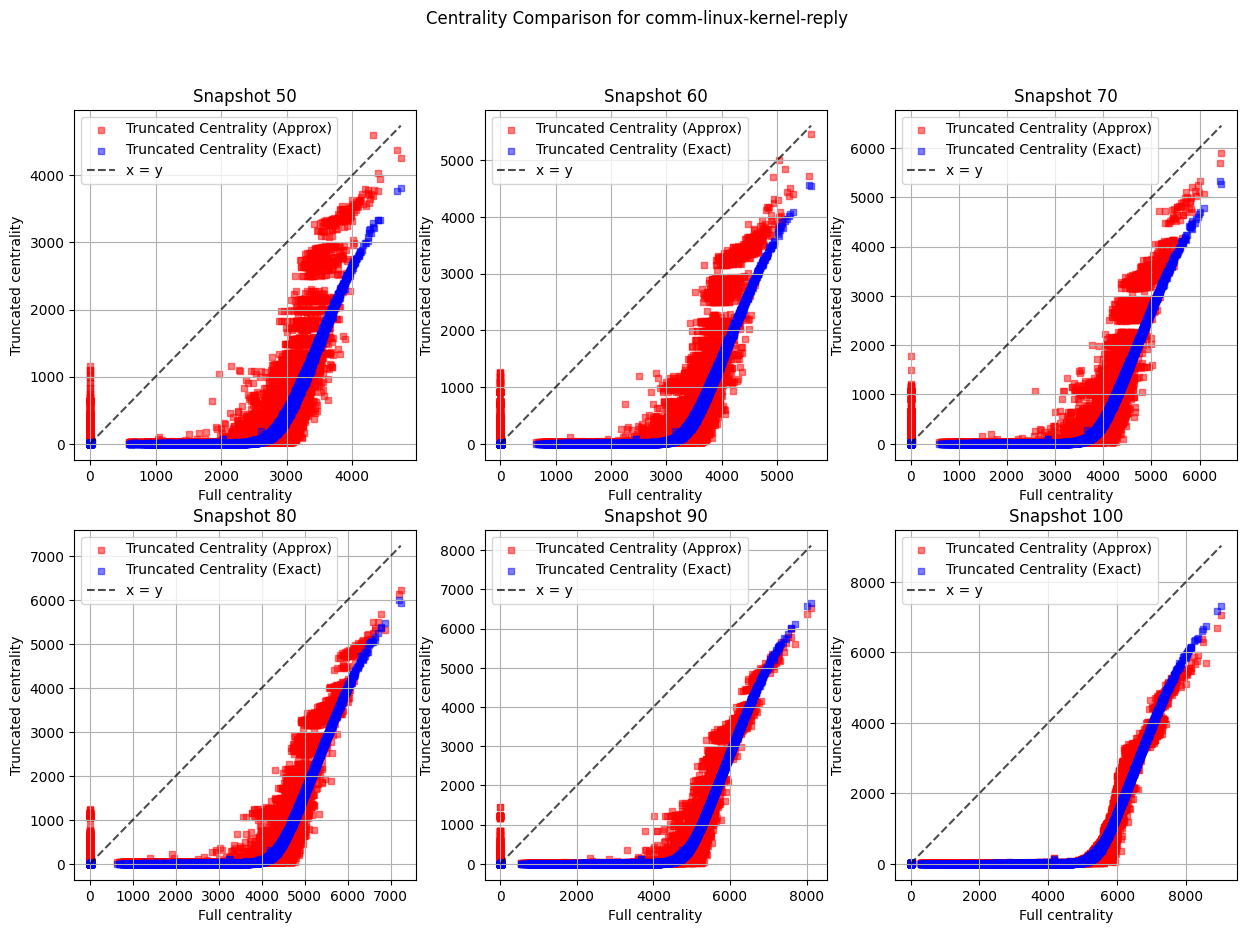

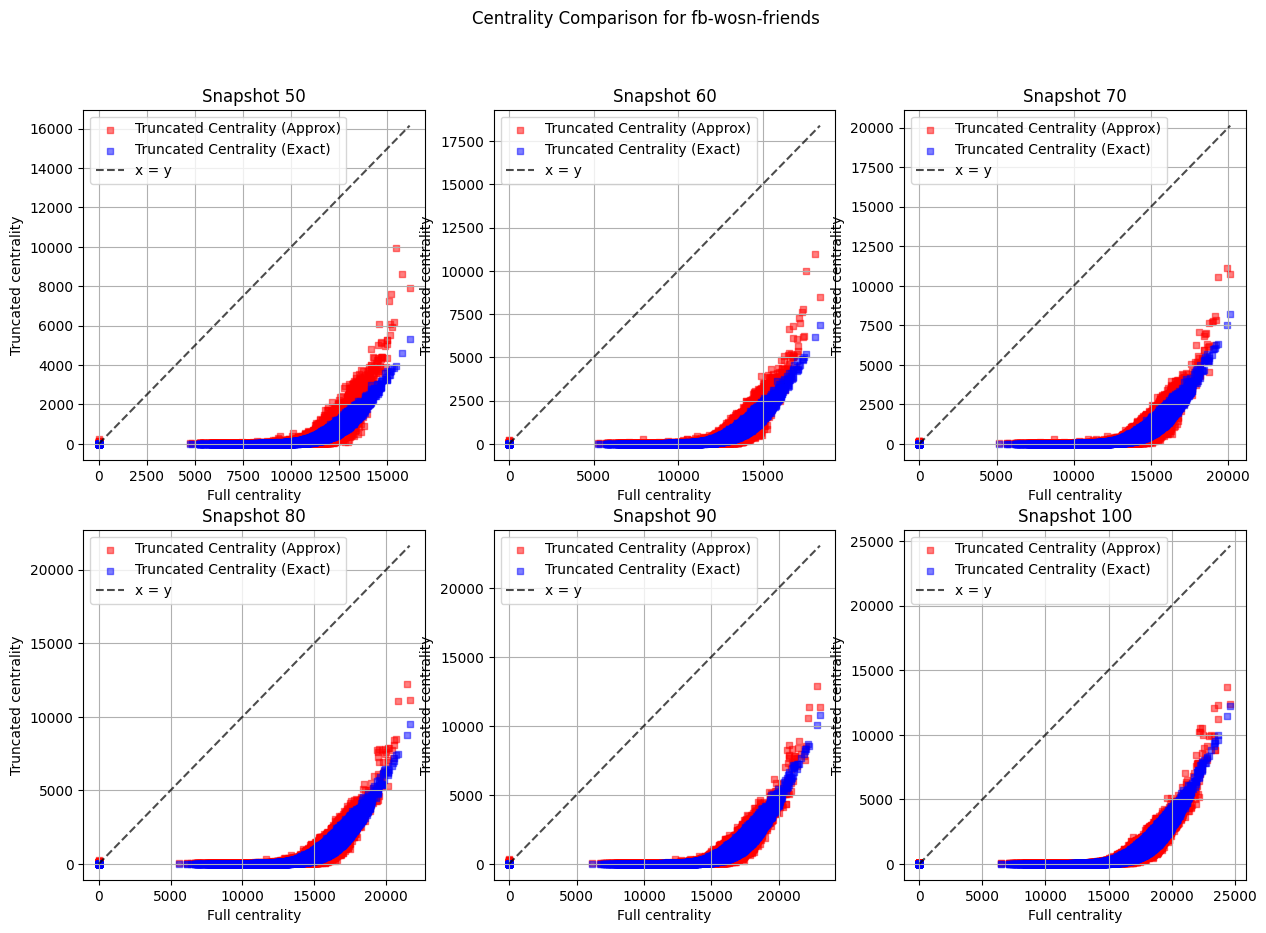

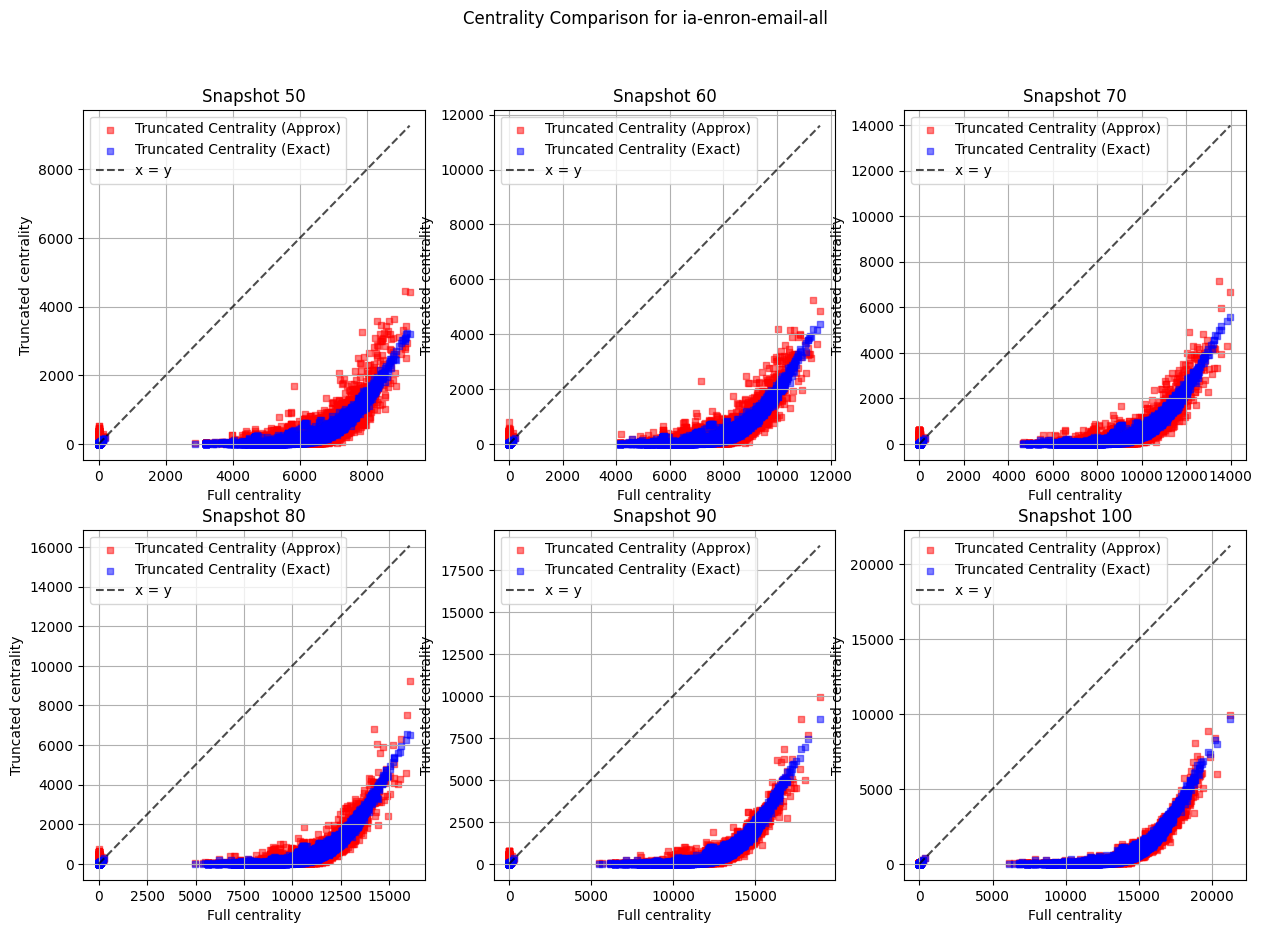

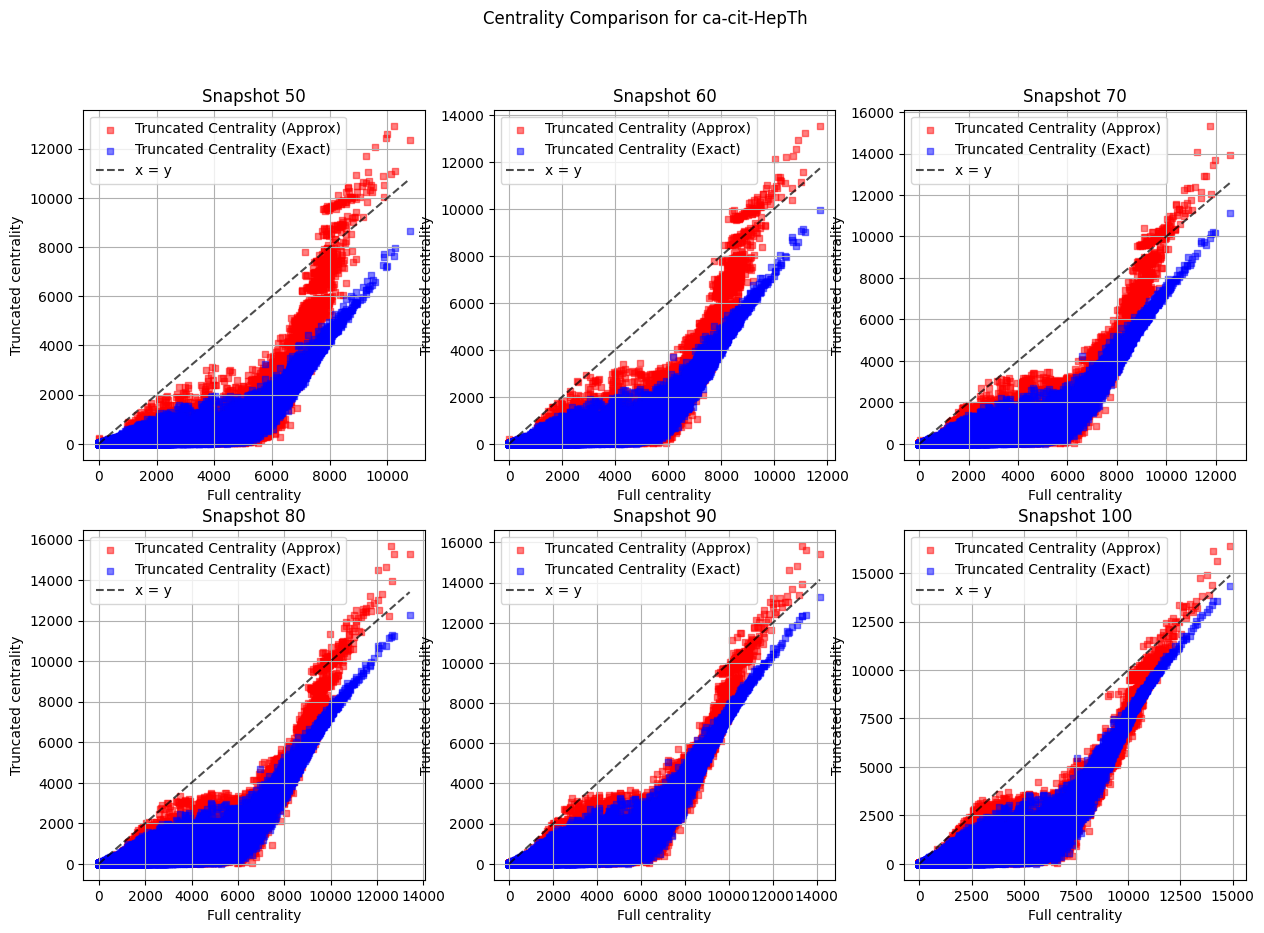

In [ ]:
# run experiments on the first 
data = []
for dataset in datasets:
    experiment(dataset)
    

Observations:
- The approximated truncated centrality is unstable for isolated nodes due to the functioning of KMV counters.
- There is a positive correlation between the full-exact centrality and the truncated centrality.
- The correlations are non-linear.

# Rank Correlation 
Based on the plots above, it's evident that the two centrality scores are highly correlated. However, this correlation is not linear. Therefore, instead of calculating the linear correlation, we compute the rank correlation between the ranks assigned by the two scores.

Observe that for isolated nodes (seen at the bottom left of each plot), the approximated 2-hop centrality estimation is unstable. This instability is caused by the counters used in the approximation process. Consequently, when comparing the ranks between the full centrality and the 2-hop approximated centrality, we explicitly discard nodes with low scores. This is justified by the fact that, when evaluating ranks, the primary focus is typically on the top-scoring nodes.

Specifically, we calculate both Spearman's Rank Correlation Coefficient and Kendall's Tau between the exact full ranking and the rankings derived from the truncated centrality scores, both exact and approximated, over the top-$k$% of nodes, where $k = 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9$.


In [ ]:
from scipy import stats

def plotCorrelations(ax, snap, dataset, alpha = lambda x : 1/x):
    ids, centralities, trunkated_centralities_exact, trunkated_centralities_appx  = computeCentralityForDataset(dataset, alpha)

    full_to_trunkated = [(x,y,w,z) for x,y, w, z in zip(centralities, trunkated_centralities_exact, trunkated_centralities_appx, ids)]
    full_to_trunkated.sort(key=lambda x: x[0], reverse=True)
    full_to_trunkated_t = []
    percents = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]
    correlations_exact_spearman = []
    correlations_appx_spearman = []  
    correlations_exact_kendall = []
    correlations_appx_kendall = []  
    for i in percents:
        full_to_trunkated_t = full_to_trunkated[:int(len(full_to_trunkated)*i)]
        centralities, trunkated_centralities_exact, trunkated_centralities_appx, ids = zip(*full_to_trunkated_t)

        corr_exact = stats.spearmanr(centralities, trunkated_centralities_exact).statistic
        corr_appx = stats.spearmanr(centralities, trunkated_centralities_appx).statistic
        correlations_exact_spearman.append(corr_exact)
        correlations_appx_spearman.append(corr_appx)

        corr_exact = stats.kendalltau(centralities, trunkated_centralities_exact).statistic
        corr_appx = stats.kendalltau(centralities, trunkated_centralities_appx).statistic
        correlations_exact_kendall.append(corr_exact)
        correlations_appx_kendall.append(corr_appx)
    # Plot the correlations
    ax.scatter(
        percents, correlations_appx_spearman,
        label='(Apx) Spearman Corr', color='red', 
        marker='s', alpha=0.5, s=20  
    )

    ax.scatter(
        percents, correlations_exact_spearman,
        label='(Ex) Spearman Corr', color='blue', 
        marker='s', alpha=0.5, s=20  
    )

    ax.scatter(
        percents, correlations_appx_kendall,
        label='(Apx) Kendall\'s Tau', color='red', 
        marker='*', alpha=0.5, s=20  
    )

    ax.scatter(
        percents, correlations_exact_kendall,
        label='(Ex) Kendall\'s Tau', color='blue', 
        marker='*', alpha=0.5, s=20  
    )

    # Set labels and title
    ax.set_xlabel('Top-% of nodes')
    ax.set_ylabel('Correlation')
    ax.set_title(f"Snapshot {snap}")
    ax.legend(fontsize='small')
    ax.grid(True)

    return (ids, centralities, trunkated_centralities_exact, trunkated_centralities_appx), correlations_exact_spearman, correlations_appx_spearman, correlations_exact_kendall, correlations_appx_kendall   

def experiment_sper_corr(dataset_name, alpha = lambda x : 1/x):
    dataset_path = lambda y, x : f"distances/{y}_{x}%.dist"
    fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize=(15, 10))
    fig.suptitle(f"Correlation Comparison for {dataset_name}")
    for i,snap in enumerate(range(50,101,10)):
        dataset = loadData(dataset_path(dataset_name, snap))
        data = plotCorrelations(axs[i//3, i%3], snap, dataset, alpha = alpha)
    plt.show()
    return data

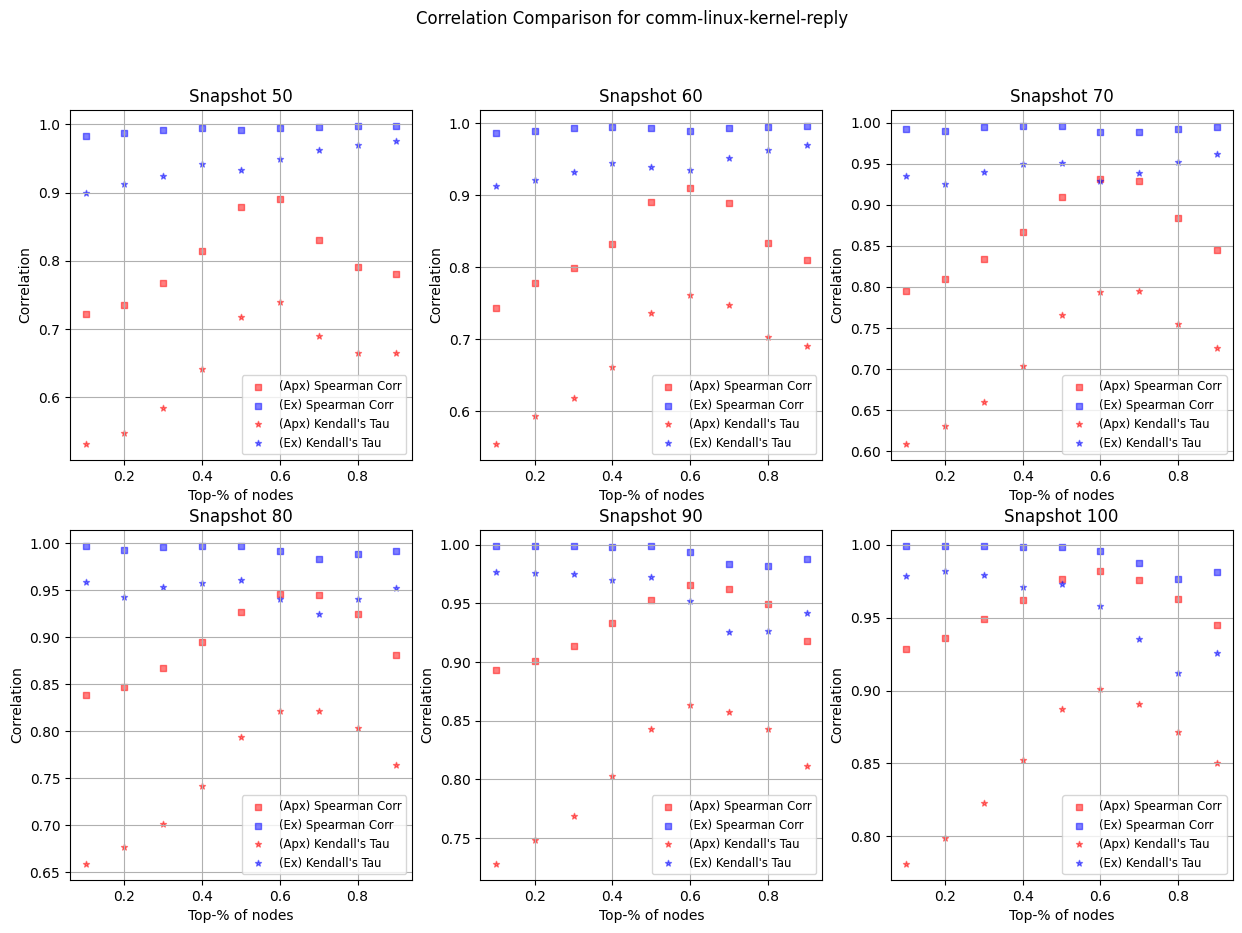

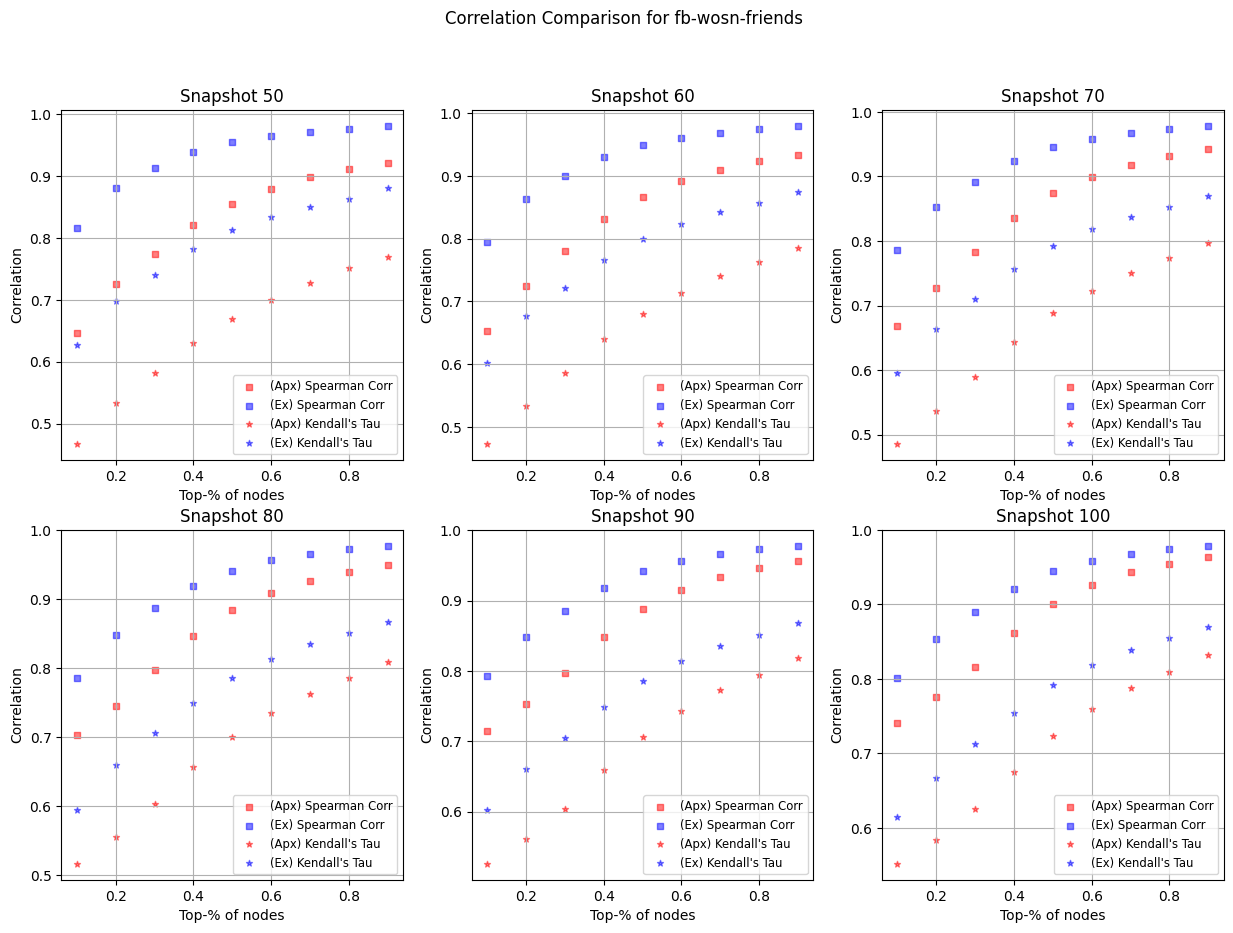

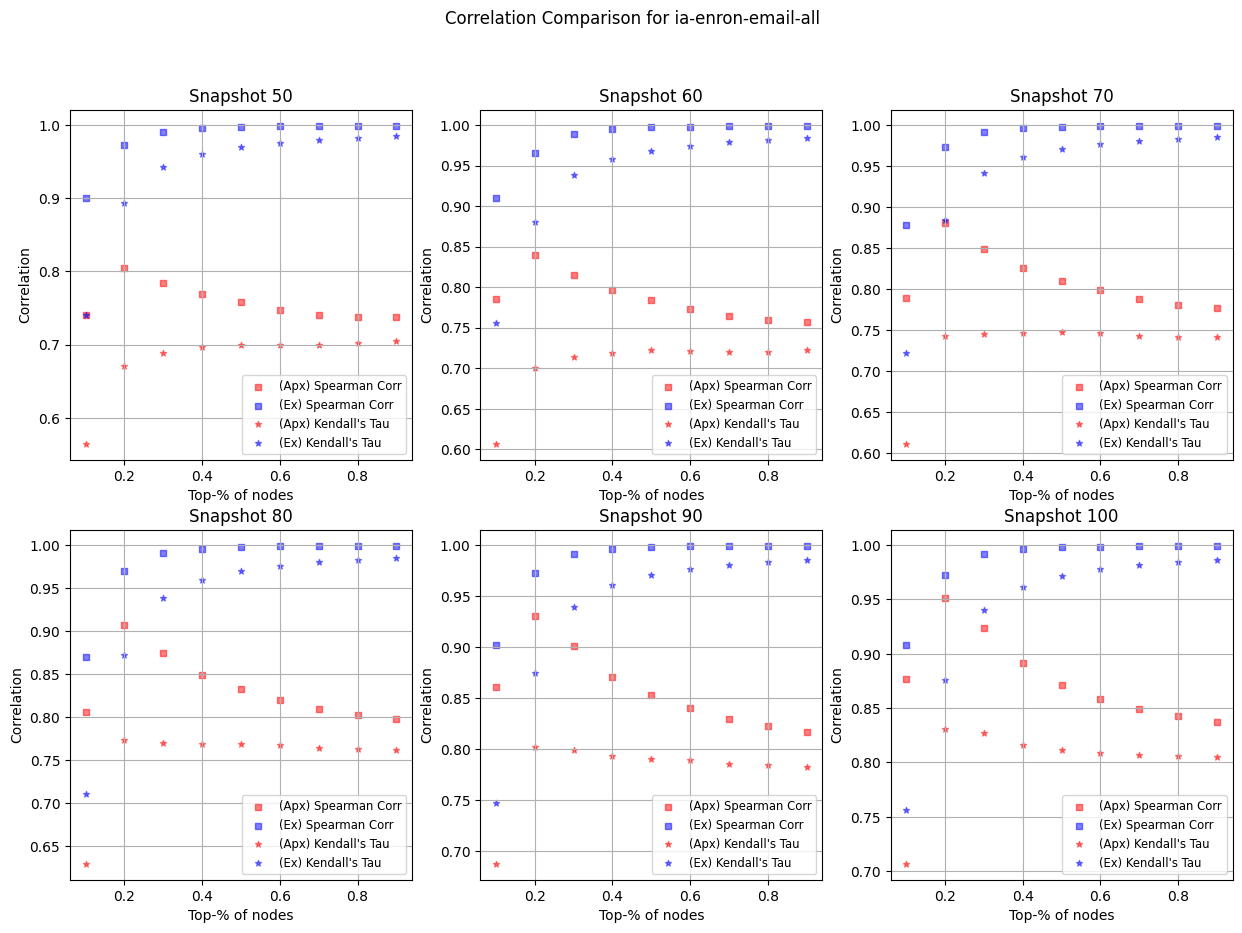

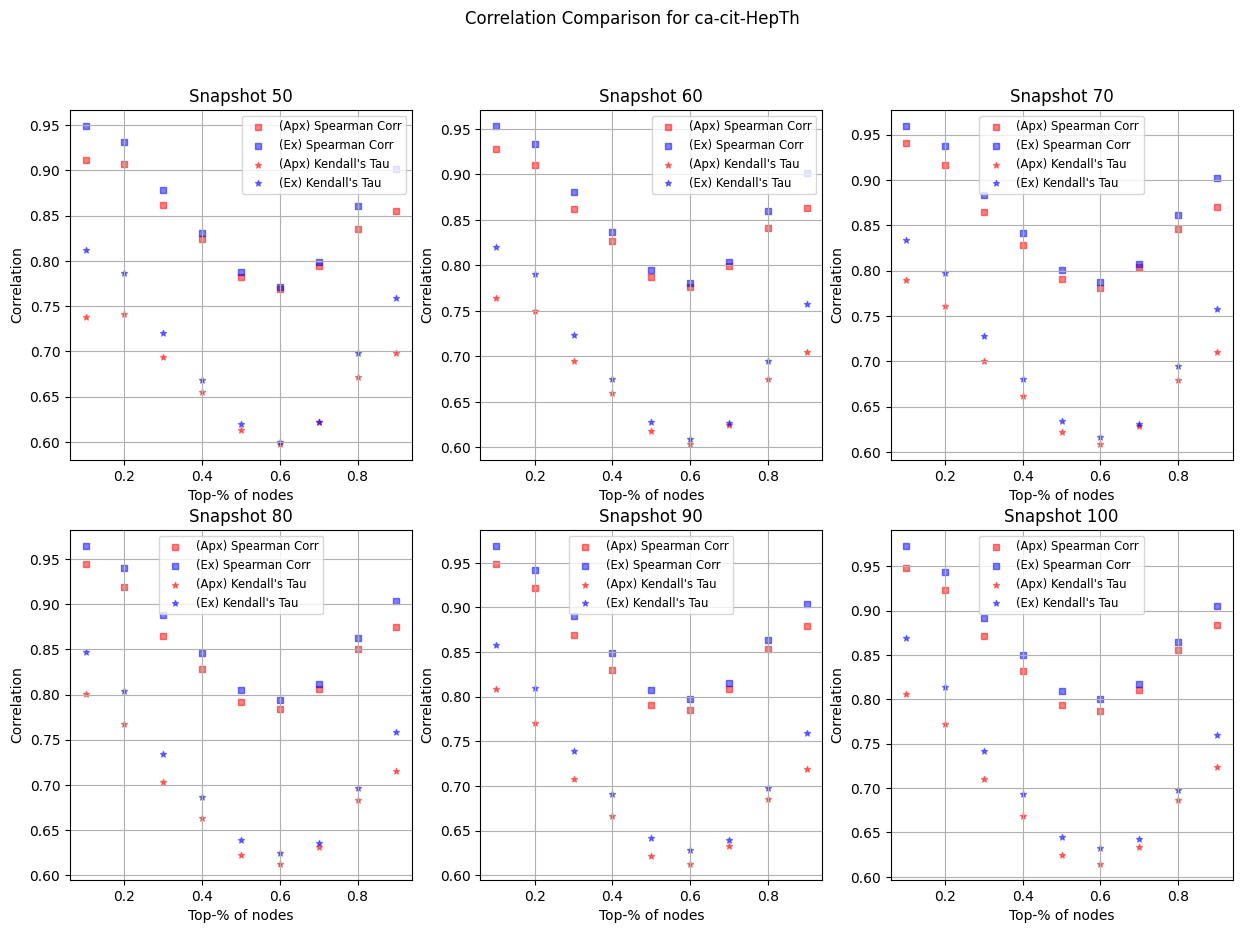

In [ ]:
# run experiments on the first 
corr_data = []
datasets = ["comm-linux-kernel-reply","fb-wosn-friends","ia-enron-email-all","ca-cit-HepTh"]
for dataset in datasets:
    experiment_sper_corr(dataset)

Now we set the function $\alpha(x) = 2^{-x}$ and we see how the correlation changes.

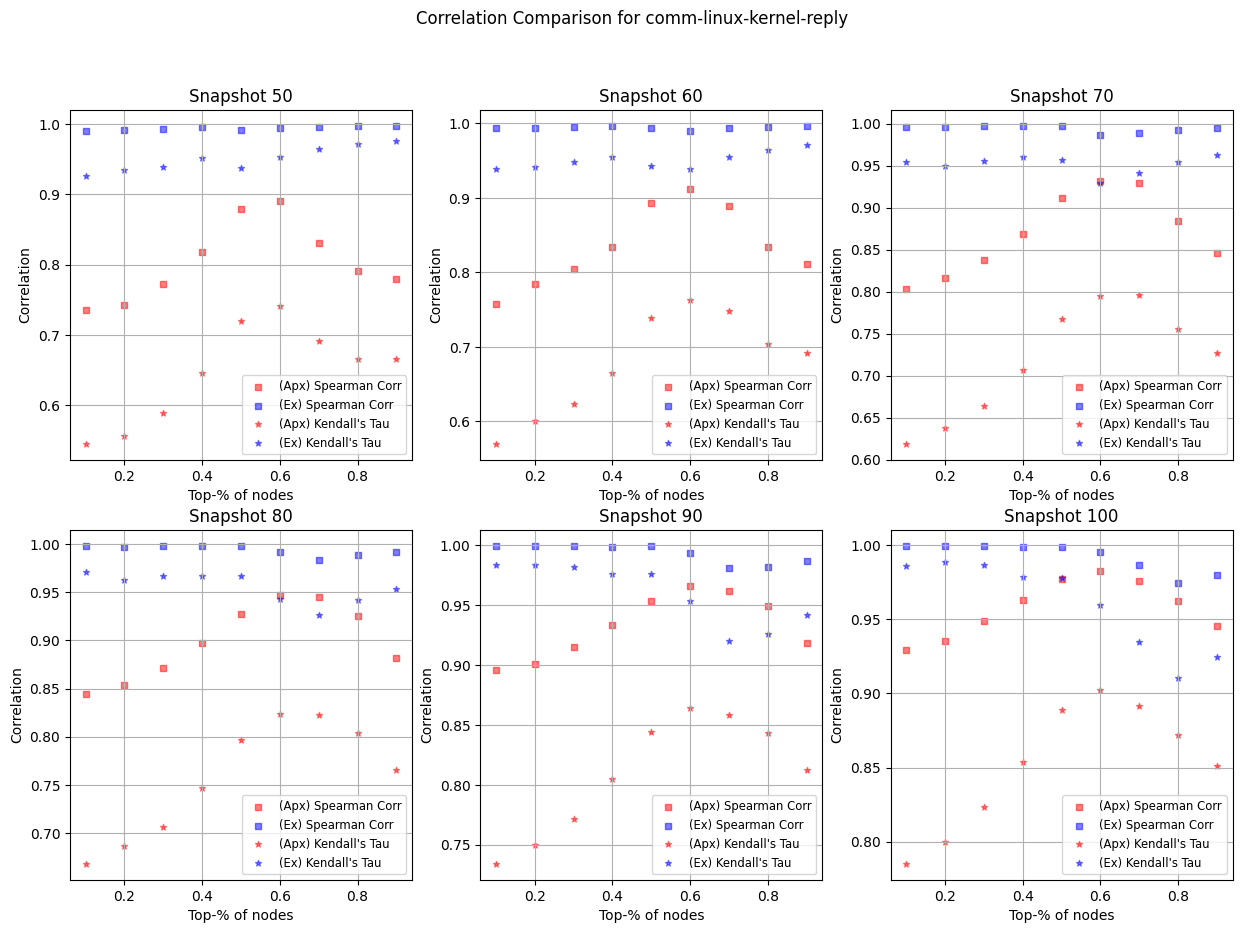

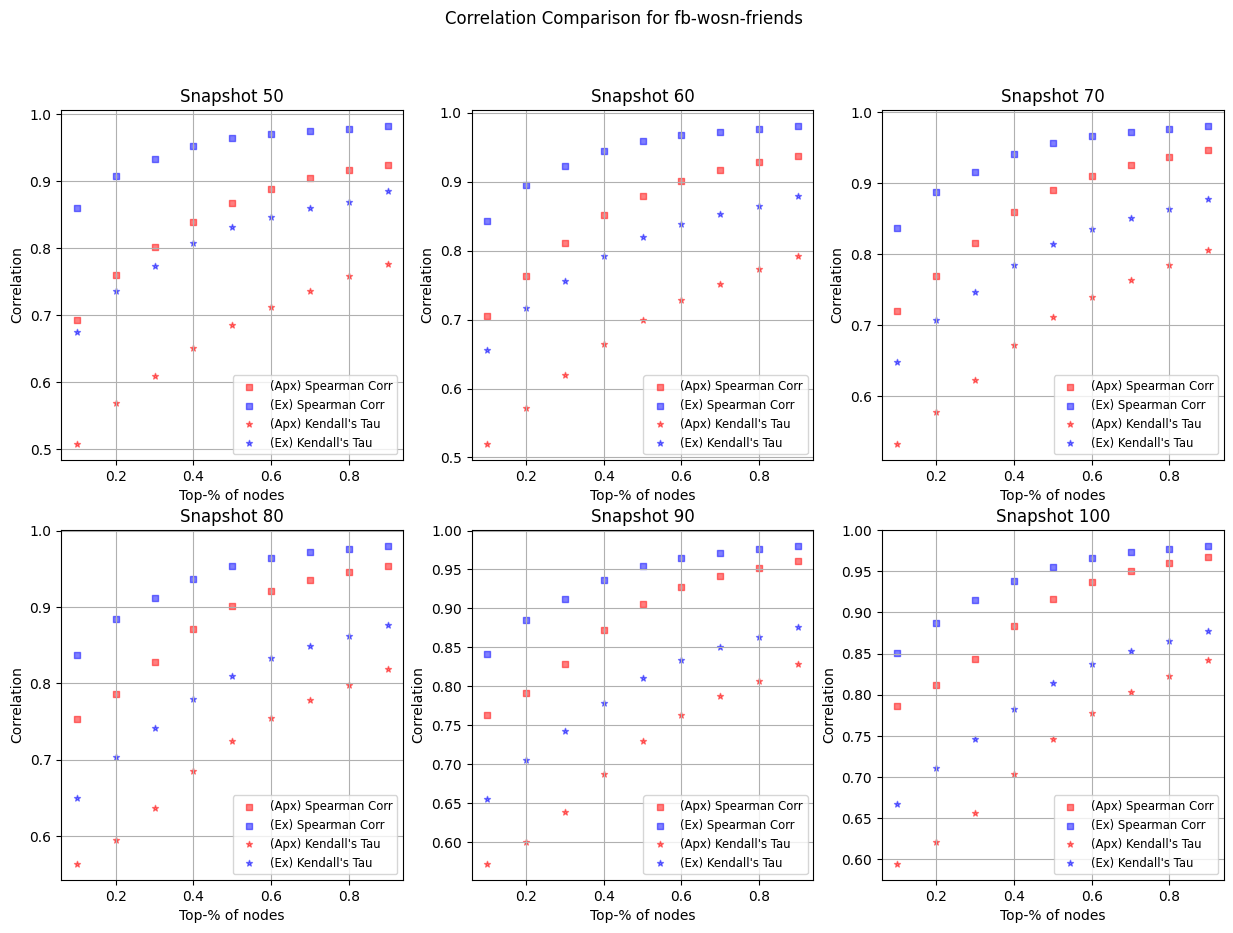

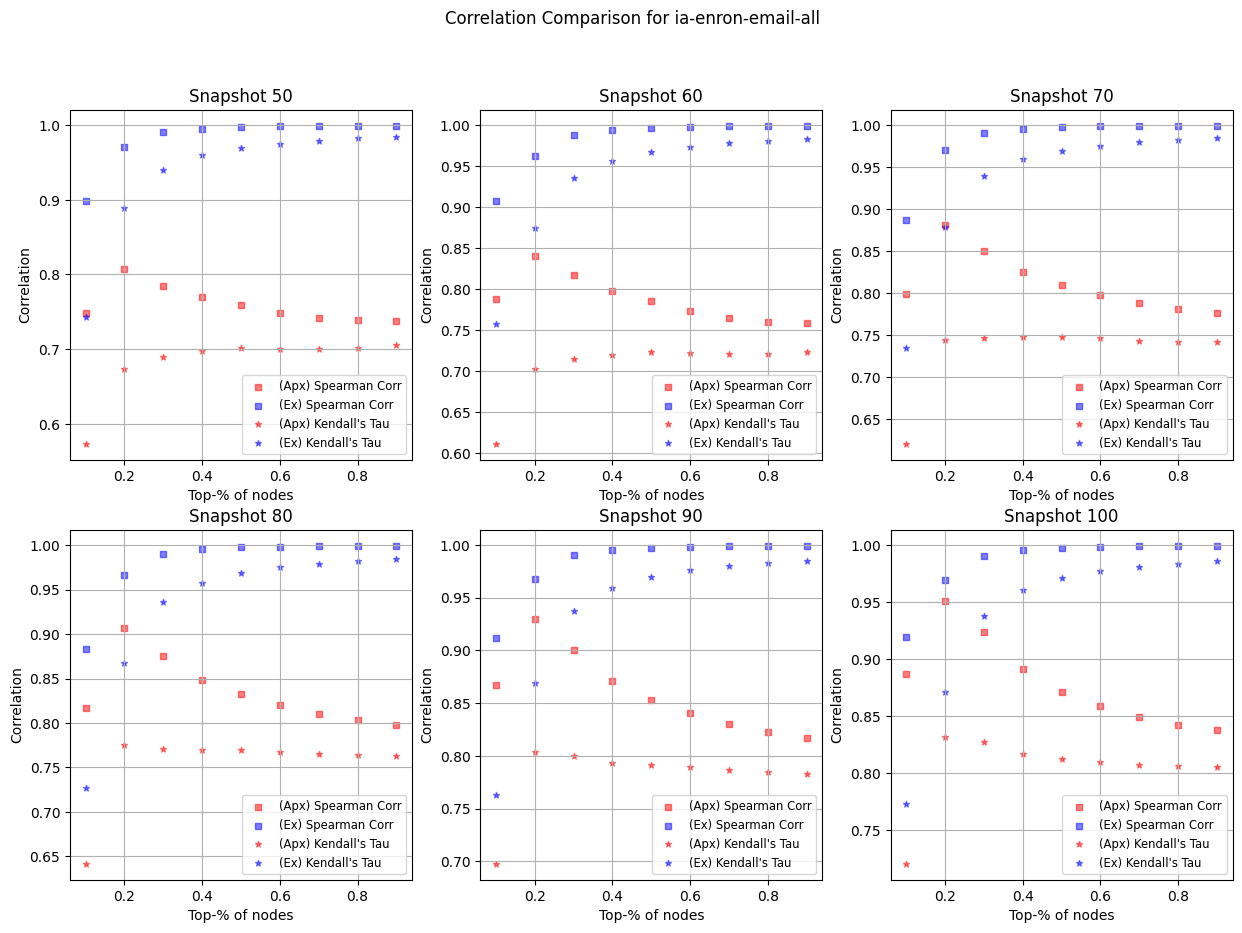

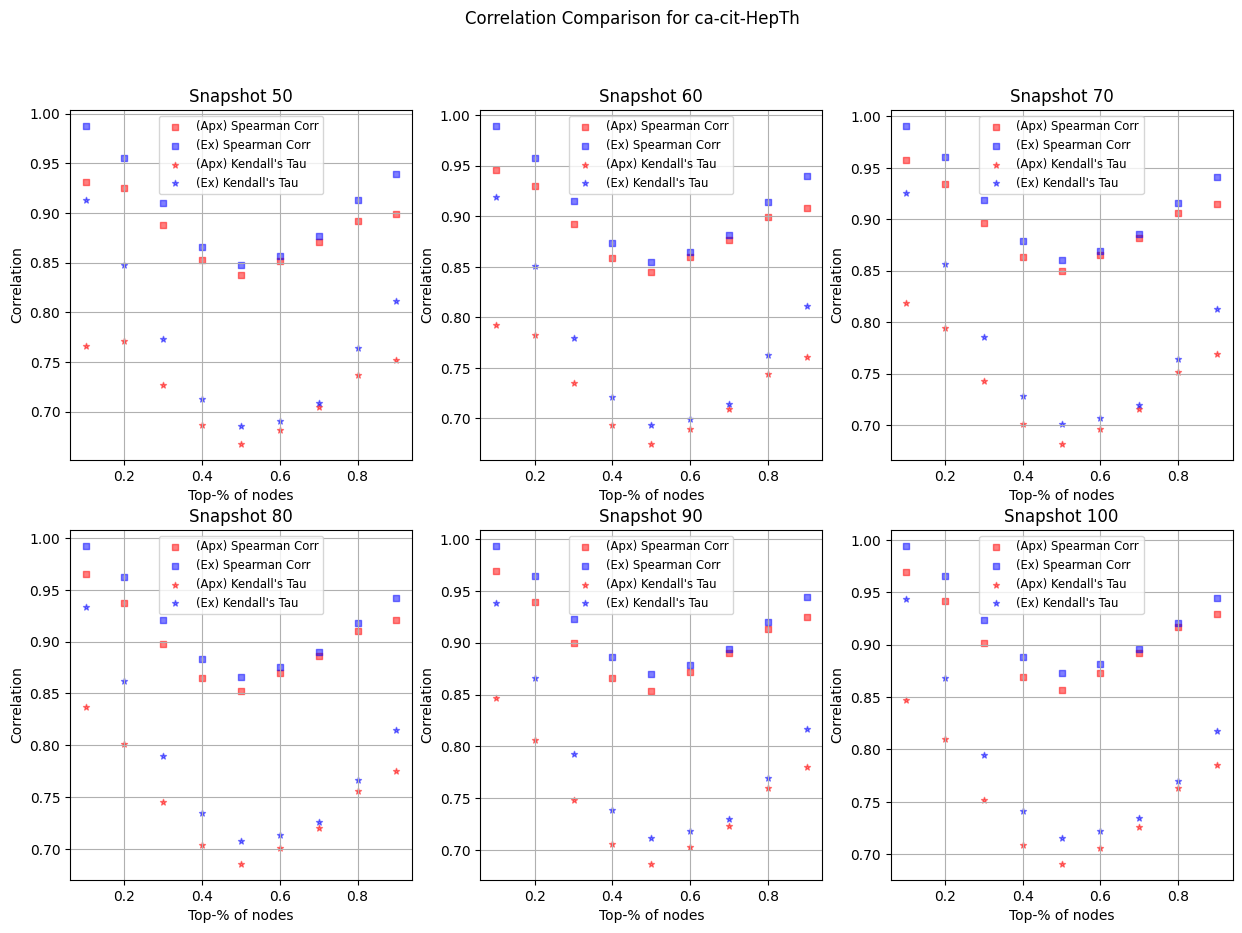

In [ ]:
# run experiments on the first 
corr_data_gen = []
datasets = ["comm-linux-kernel-reply","fb-wosn-friends","ia-enron-email-all","ca-cit-HepTh"]
for dataset in datasets:
    experiment_sper_corr(dataset, alpha = lambda x : 1/x**2)
    

# Top-K Recall 
In this section, driven by the importance of the Top-$k\%$ task, we analyze the Recall ($\frac{|U \cup U'|}{|V|k}$) between the Top-$k\%$ sets derived from the exact full centralities ($U$) and the truncated centralities ($U'$), both exact and approximated. This analysis is conducted for $k = 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.005, 0.001$.

In [100]:
def plotRecall(ax, snap, dataset, alpha = lambda x : 1/x):
    ids, centralities, trunkated_centralities_exact, trunkated_centralities_appx  = computeCentralityForDataset(dataset, alpha)

    id_to_full = [(id,c) for id,c in zip(ids, centralities)]
    id_to_trunkated_exact = [(id,c) for id,c in zip(ids, trunkated_centralities_exact)]
    id_to_trunkated_appx = [(id,c) for id,c in zip(ids, trunkated_centralities_appx)]
    id_to_full.sort(key=lambda x: x[1], reverse=True)
    id_to_trunkated_appx.sort(key=lambda x: x[1], reverse=True)
    id_to_trunkated_exact.sort(key=lambda x: x[1], reverse=True)
    percents = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0.005, 0.001]
    recall_exact = []
    recall_appx = []  
    for i in percents:
        full_topk = id_to_full[:int(len(id_to_full)*i)]
        trunkated_topk_exact = id_to_trunkated_exact[:int(len(id_to_trunkated_exact)*i)]
        trunkated_topk_appx = id_to_trunkated_appx[:int(len(id_to_trunkated_appx)*i)]
        # extract the ids from the tuples
        full_topk_ids = set([x[0] for x in full_topk])
        trunkated_topk_exact_ids = set([x[0] for x in trunkated_topk_exact])
        trunkated_topk_appx_ids = set([x[0] for x in trunkated_topk_appx])
        # compute the recall
        recall_exact.append(len(full_topk_ids.intersection(trunkated_topk_exact_ids))/len(full_topk_ids))
        recall_appx.append(len(full_topk_ids.intersection(trunkated_topk_appx_ids))/len(full_topk_ids))
        
    # Plot the correlations
    ax.scatter(
        percents, recall_appx,
        label='(Apx) Recall', color='red', 
        marker='s', alpha=0.5, s=20  
    )

    ax.scatter(
        percents, recall_exact,
        label='(Ex) Recall', color='blue', 
        marker='s', alpha=0.5, s=20  
    )

    # Set labels and title
    ax.set_xlabel('Top-% of nodes')
    ax.set_ylabel('Correlation')
    ax.set_title(f"Snapshot {snap}")
    ax.legend(fontsize='small')
    ax.grid(True)

    return (ids, centralities, trunkated_centralities_exact, trunkated_centralities_appx), recall_exact, recall_appx   

def experiment_topk(dataset_name, alpha = lambda x : 1/x):
    dataset_path = lambda y, x : f"distances/{y}_{x}%.dist"
    fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize=(15, 10))
    fig.suptitle(f"Top-k Recall comparison for {dataset_name}")
    for i,snap in enumerate(range(50,101,10)):
        dataset = loadData(dataset_path(dataset_name, snap))
        data = plotRecall(axs[i//3, i%3], snap, dataset, alpha = alpha)
    plt.show()
    return data

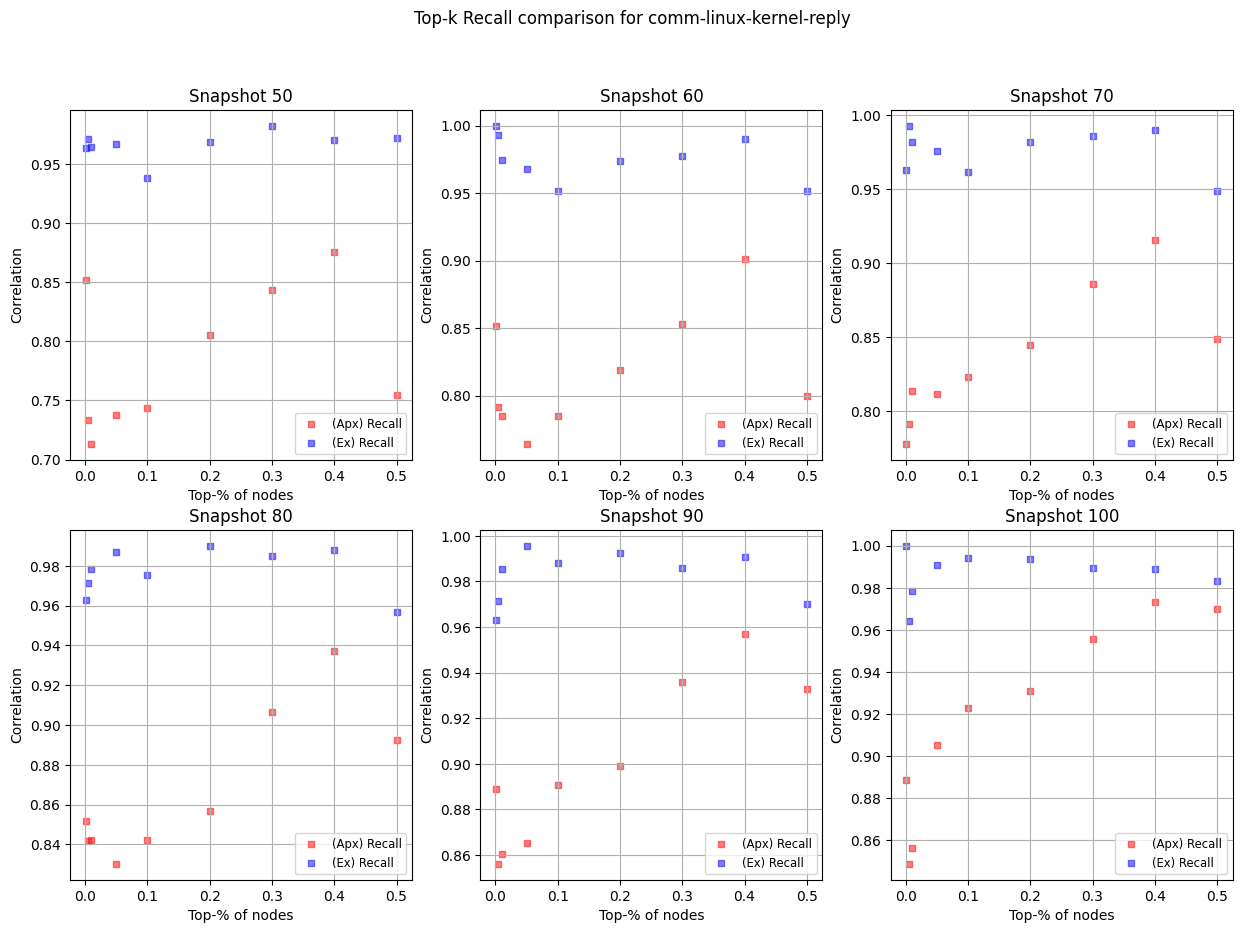

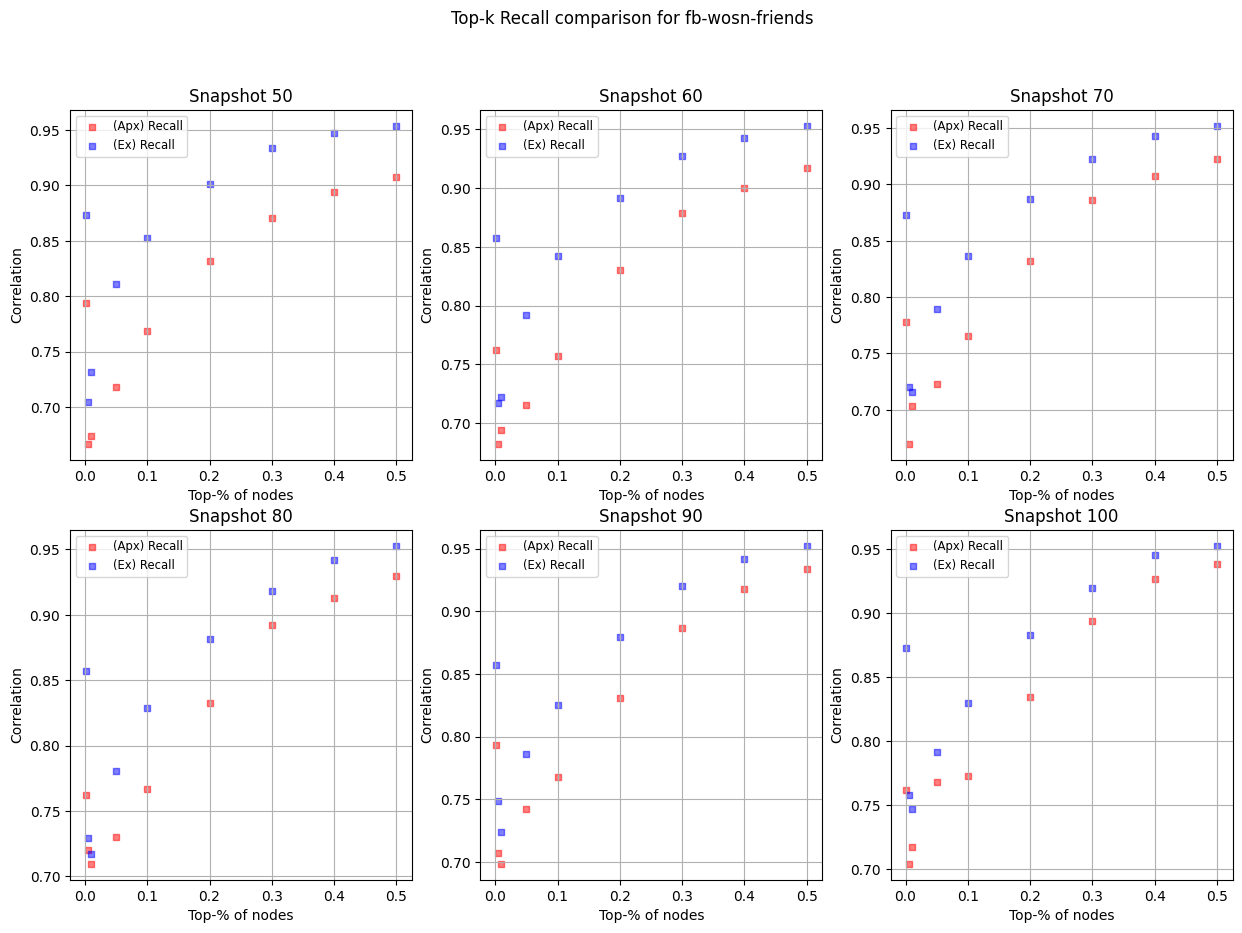

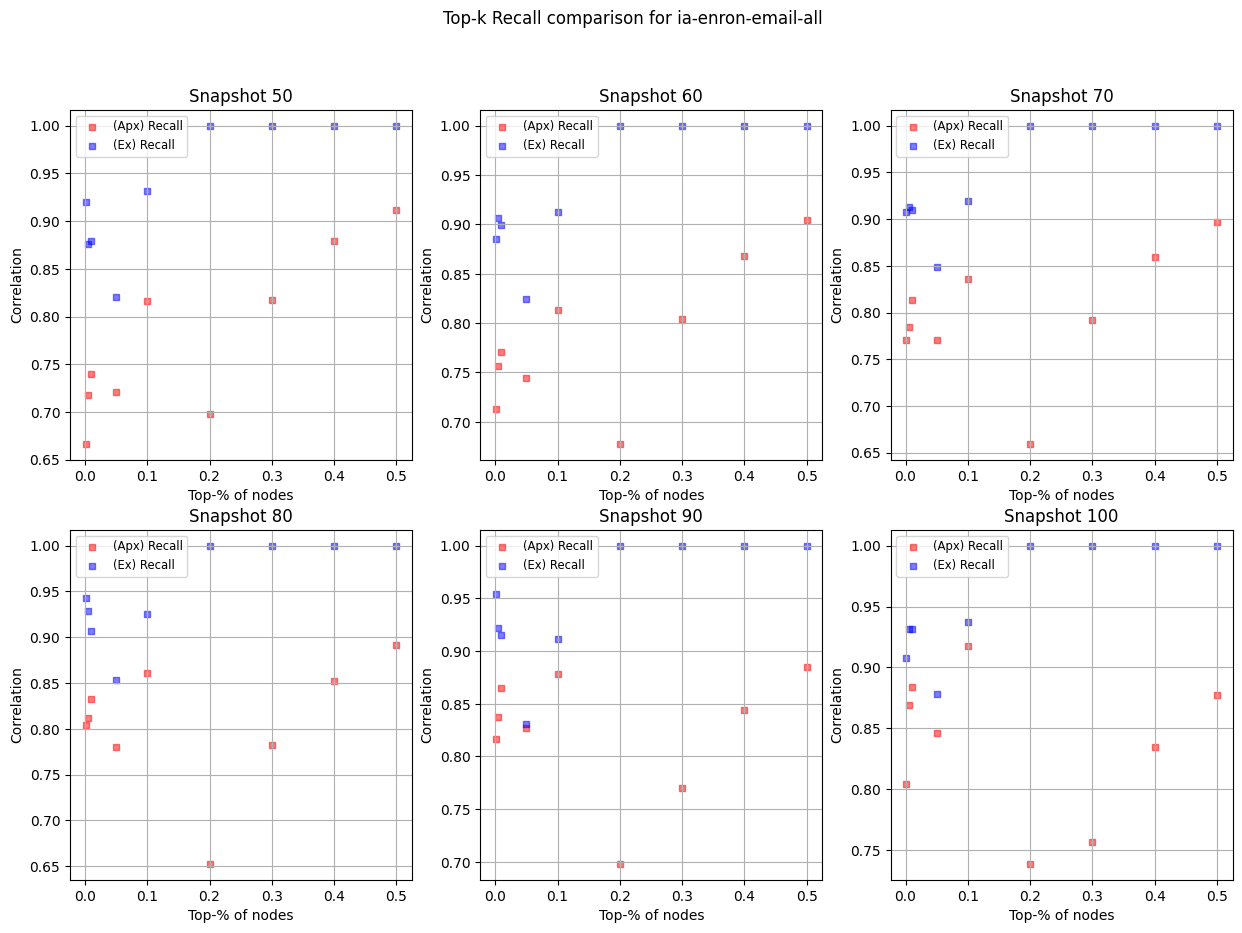

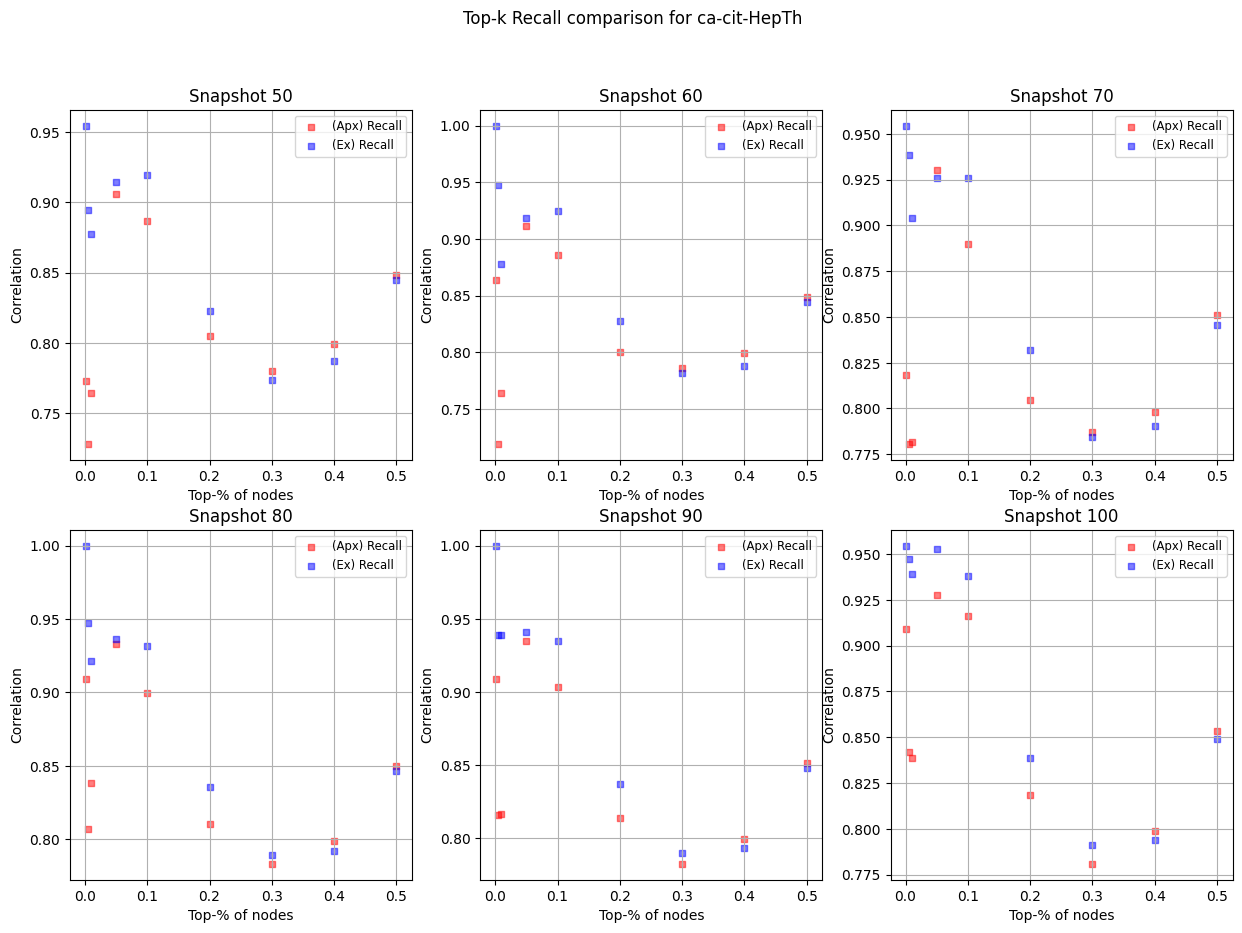

In [ ]:
for dataset in datasets:
    experiment_topk(dataset)

# h-balls growth rate analysis 
In this final section, we examine how the BFS layers expand as the distance from the source node increases. Specifically, for each node $u$, we compute two sequences of values, $\{b(u)_t\}_{t=2,\dots,d}$ and $\{l(u)_t\}_{t=2,\dots,d}$, where $d$ is the effective diameter of the graph. These sequences are defined by $b(u)_t = \frac{|B_t(u)|}{|B{t-1}(u)|}$ and $l(u)_t = \frac{|L_t(u)|}{|L{t-1}(u)|}$. After computing these sequences, we extract the medians $m_t = \text{median}(\{b(u)_t : u \in V : \text{diam}(u) \geq t\})$ and $m'_t = \text{median}(\{l(u)_t : u \in V : \text{diam}(u) \geq t\})$, corresponding to the balls and the layers, respectively. This process is repeated for each $t = 1, \dots, d$, and we then plot the resulting medians together with their interquartile range ($Q_3 - Q_1$).

In [10]:
def compute_effective_diameter(dataset):
    # Find the maximum distance (diameter) for the graph
    max_distance = max([len(node[2]) for node in dataset])  # Assuming node[2] is the layers list
    
    # Initialize a list to store global distribution of distances
    global_distance_counts = np.zeros(max_distance)
    
    # Iterate over all nodes to accumulate the distance distributions
    for node in dataset:
        _, _, layers = node  # layers contain the number of nodes at each distance
        
        for d in range(1, len(layers)):  # Start from distance 1 up to max distance
            global_distance_counts[d - 1] += layers[d]
    
    # Now calculate the effective diameter by finding the 90th percentile of the distribution
    total_nodes = sum(global_distance_counts)  # Total number of nodes in the graph
    cumulative_counts = np.cumsum(global_distance_counts)  # Cumulative sum of distances
    
    # Find the smallest distance such that the cumulative count is at least 90% of the total
    effective_diameter = np.searchsorted(cumulative_counts, 0.9 * total_nodes)
    
    # If the exact 90th percentile is needed, use np.percentile, but with this method we're computing the closest value.
    
    return effective_diameter + 1  # Return 1-based effective diameter

# we have to compute the growth rate for each node in the dataset, then compute the means and plot them 
def plotGrowth(ax, snap, dataset, alpha = lambda x : 1/x):

    # Pre-calculate the diameter once
    diameter = compute_effective_diameter(dataset)
    #print(f"Effective diameter: {diameter}")
    # Initialize growth arrays as np arrays (more efficient)
    growths_layers = np.full((len(dataset), diameter - 1), np.nan)
    growths_balls = np.full((len(dataset), diameter - 1), np.nan)
    
    for i, node in enumerate(dataset):
        _, _, layers = node
        ball = 0
        for j in range(min(len(layers) - 1, diameter - 1)):
            ball += layers[j]
            growths_layers[i, j] = layers[j + 1] / layers[j]
            growths_balls[i, j] = (ball + layers[j + 1]) / ball

    # Compute median and IQR (Interquartile Range)
    growths_layers_median = np.nanmedian(growths_layers, axis=0)
    growths_balls_median = np.nanmedian(growths_balls, axis=0)
    
    # Calculate IQR for each (Q3 - Q1)
    growths_layers_IQR = np.nanpercentile(growths_layers, 75, axis=0) - np.nanpercentile(growths_layers, 25, axis=0)
    growths_balls_IQR = np.nanpercentile(growths_balls, 75, axis=0) - np.nanpercentile(growths_balls, 25, axis=0)
    
    #print(f"diameter: {diameter}, growths_layers_median: {len(growths_layers_median)}, growths_balls_mean: {len(growths_balls_mean)}, growths_layers_IQR: {len(growths_layers_IQR)}, growths_balls_std: {len(growths_balls_std)}")
    # X-axis values based on the diameter
    x_axis = np.arange(2, diameter + 1)

    # Plotting with error bars
    ax.errorbar(x_axis, growths_balls_median, yerr=growths_balls_IQR, fmt='o', label='Growth by balls', color='red', ecolor='red', capsize=5)
    ax.errorbar(x_axis, growths_layers_median, yerr=growths_layers_IQR, fmt='o', label='Growth by layers', color='blue', ecolor='blue', capsize=5)

    for i in range(len(x_axis)):
        ax.annotate(text = f"{growths_balls_median[i]:.2f}", xy = (x_axis[i], growths_balls_median[i]), textcoords="offset points", xytext=(10, 10), ha='center', fontsize=9, color='red')
        ax.annotate(text = f"{growths_layers_median[i]:.2f}", xy = (x_axis[i], growths_layers_median[i]), textcoords="offset points", xytext=(10, -10), ha='center', fontsize=9, color='blue')
    
    # Set labels and title
    ax.set_xlabel('Distance')
    ax.set_ylabel('Growth')
    ax.set_title(f"Snapshot {snap}")
    ax.legend(fontsize='small')
    ax.grid(True)

    return (growths_balls_median, growths_balls_IQR), (growths_layers_median, growths_layers_IQR)   
 


def experiment_growth(dataset_name, alpha = lambda x : 1/x):
    dataset_path = lambda y, x : f"distances/{y}_{x}%.dist"
    fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize=(15, 10))
    fig.suptitle(f"Neighborhood growth rate for {dataset_name}")
    for i,snap in enumerate(range(50,101,10)):
        #print(f"Dataset {dataset_name} snapshot {snap}")
        dataset = loadData(dataset_path(dataset_name, snap))
        plotGrowth(axs[i//3, i%3], snap, dataset, alpha = alpha)
    plt.show()
    

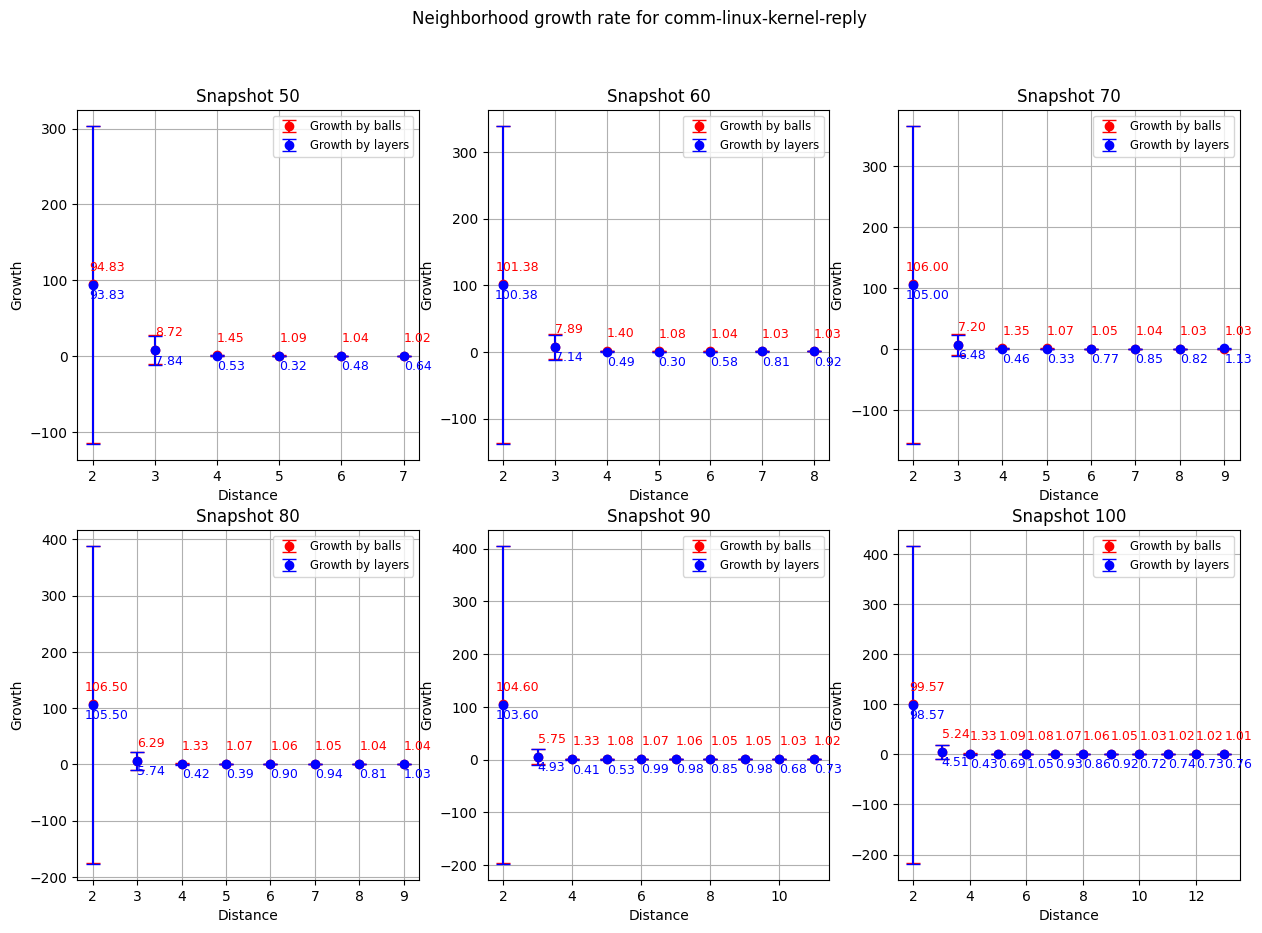

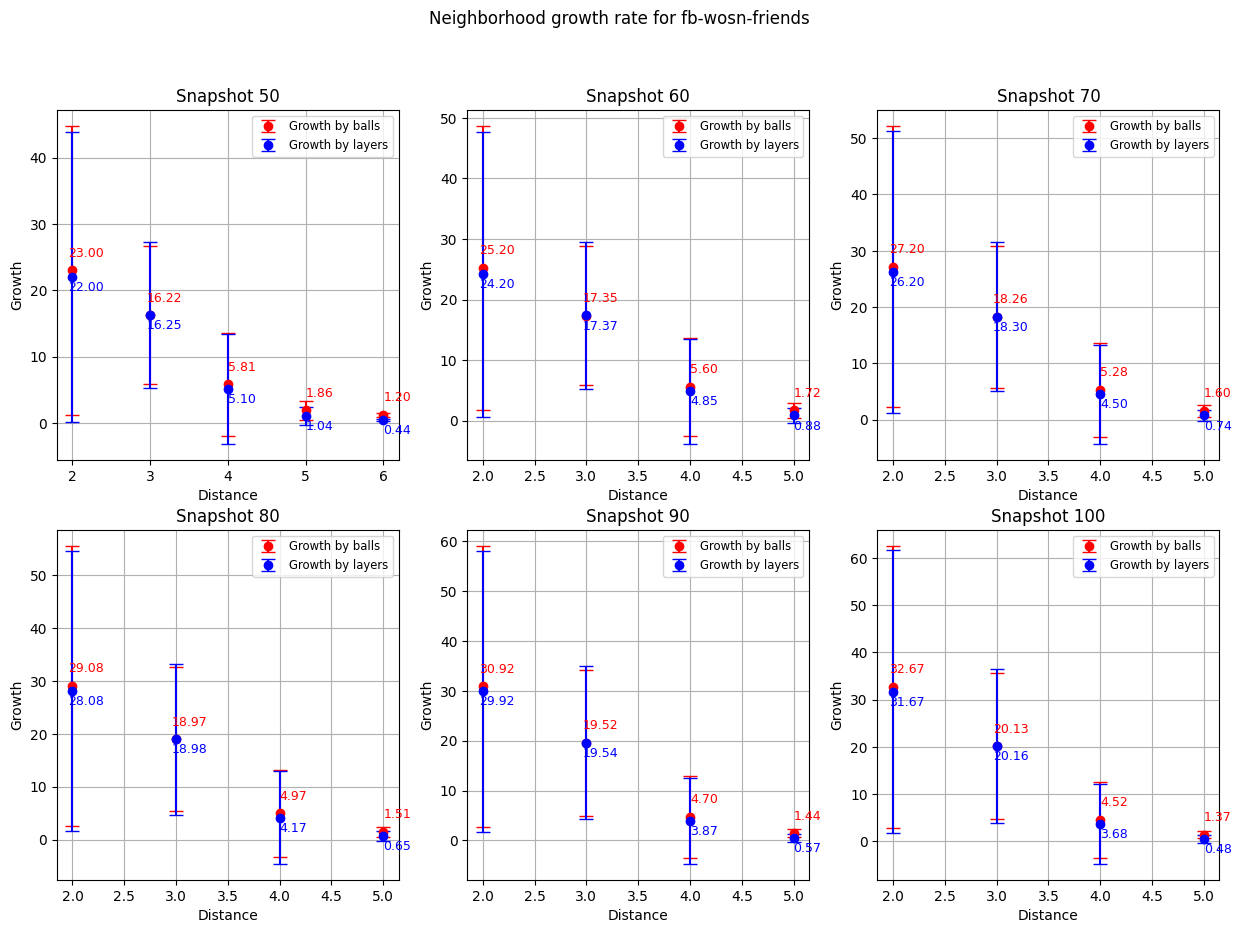

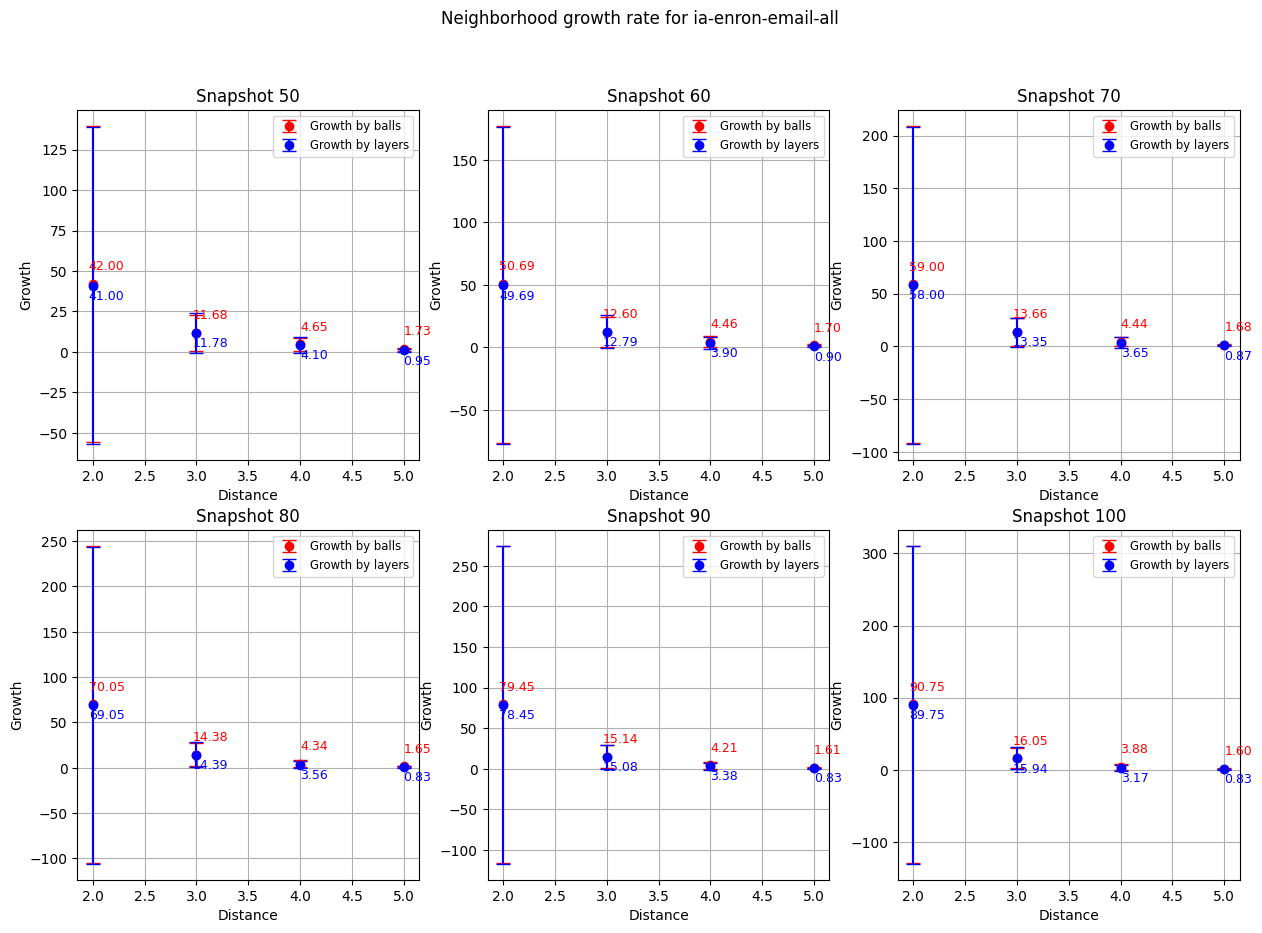

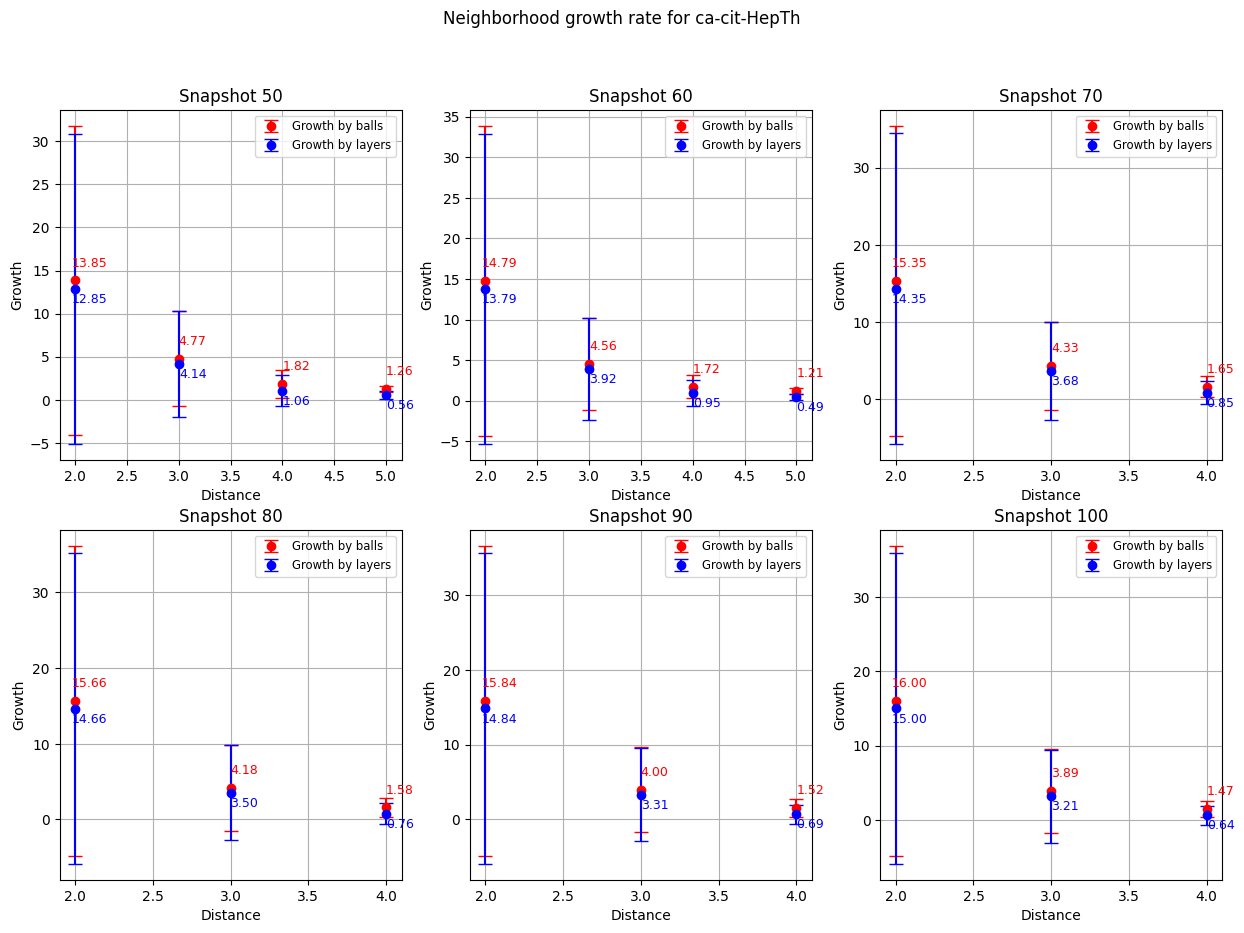

In [11]:
import matplotlib.pyplot as plt
import numpy as np

for dataset in datasets:
    experiment_growth(dataset)